In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

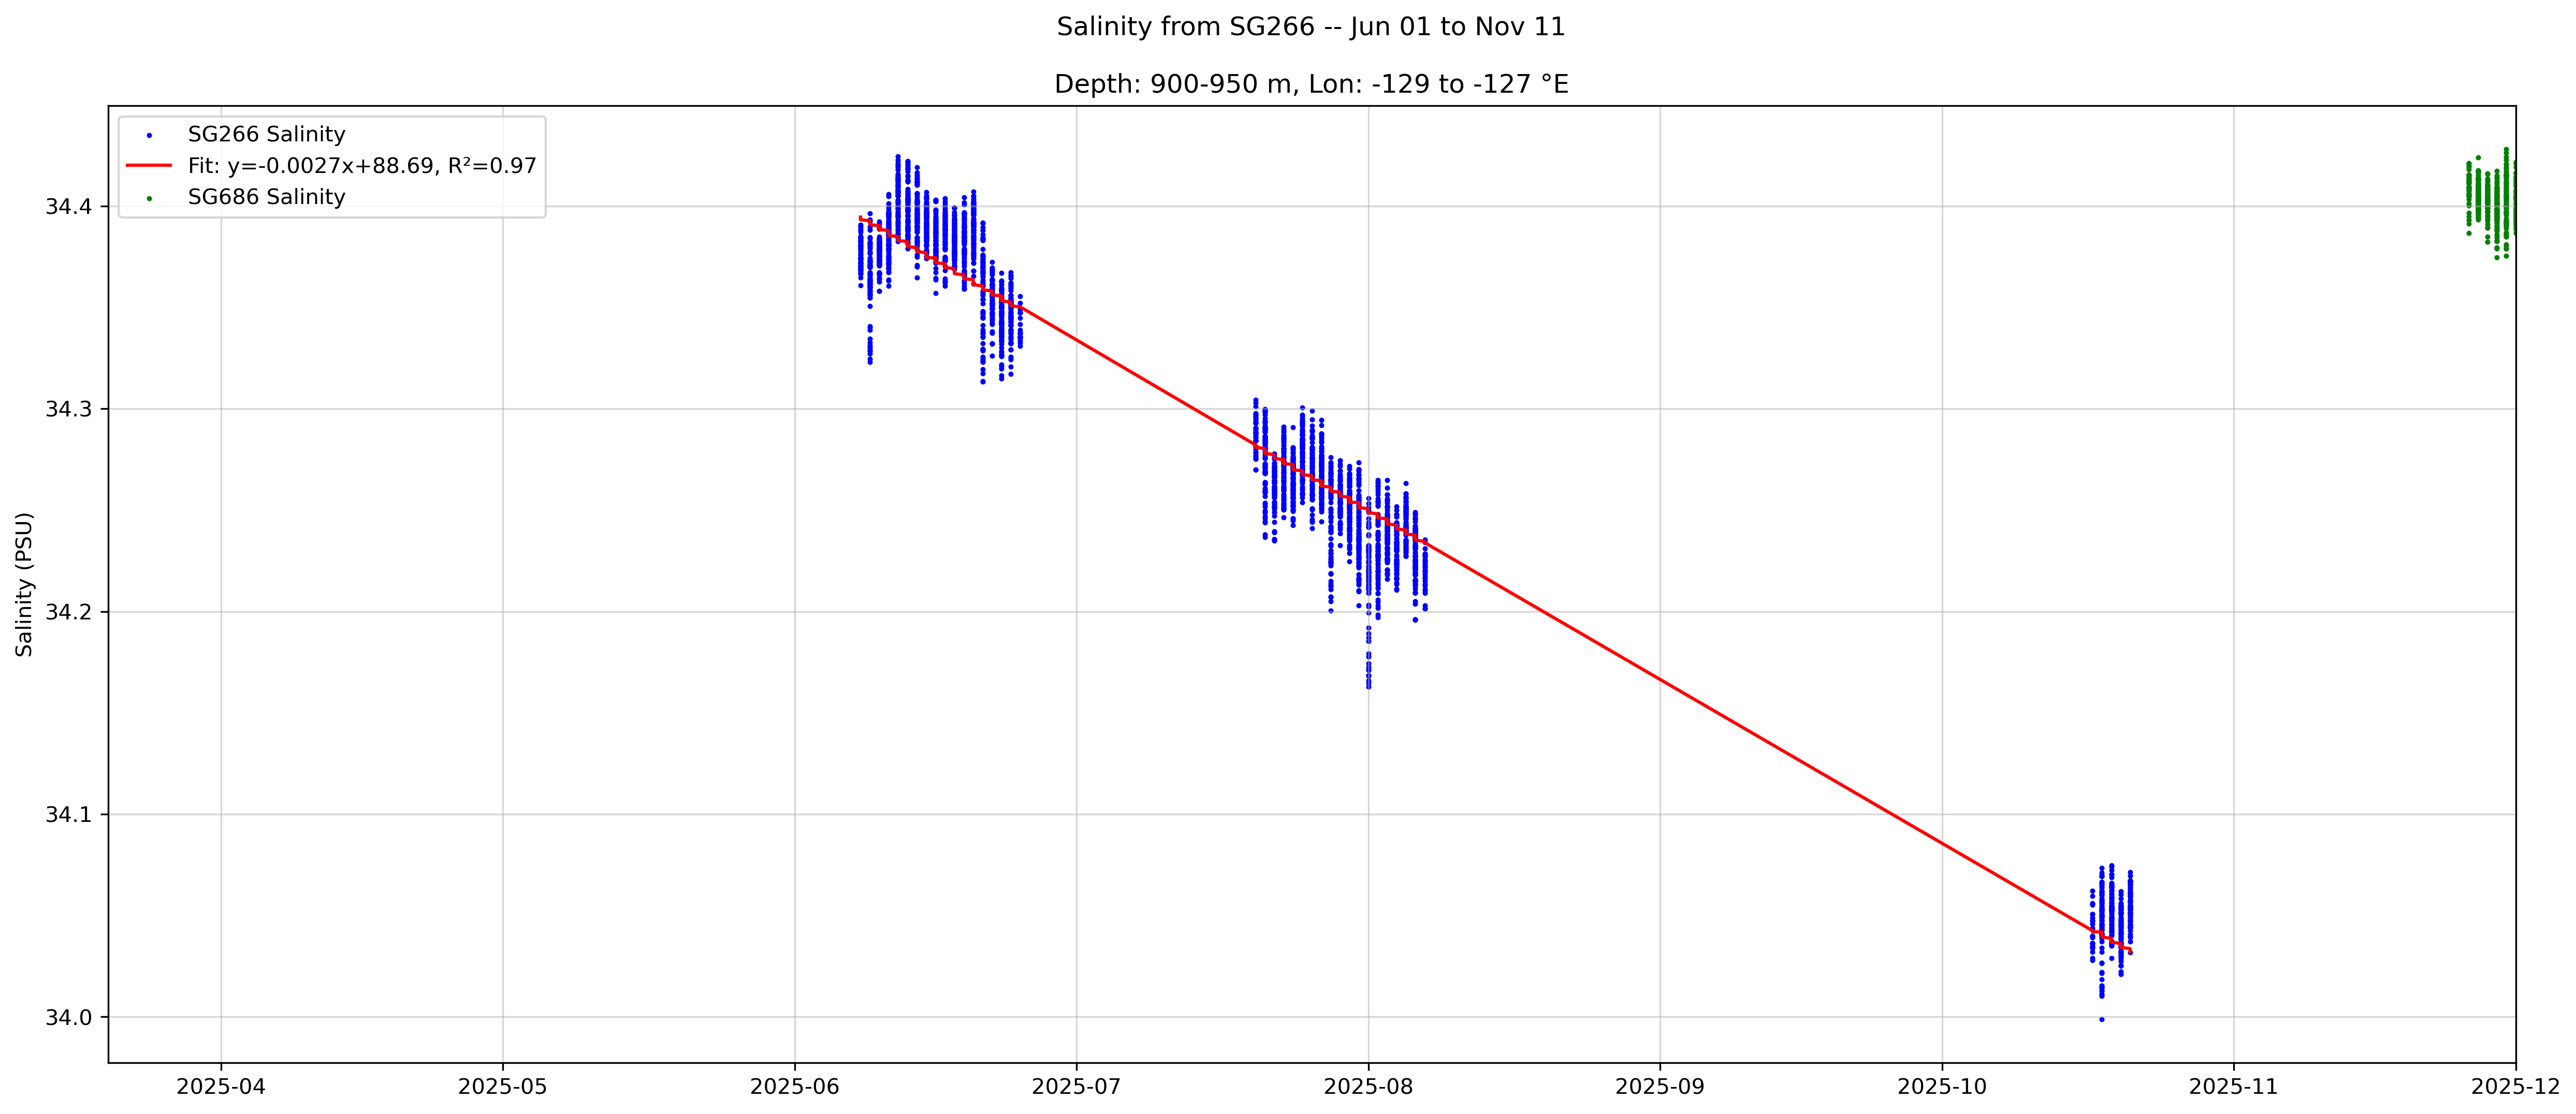

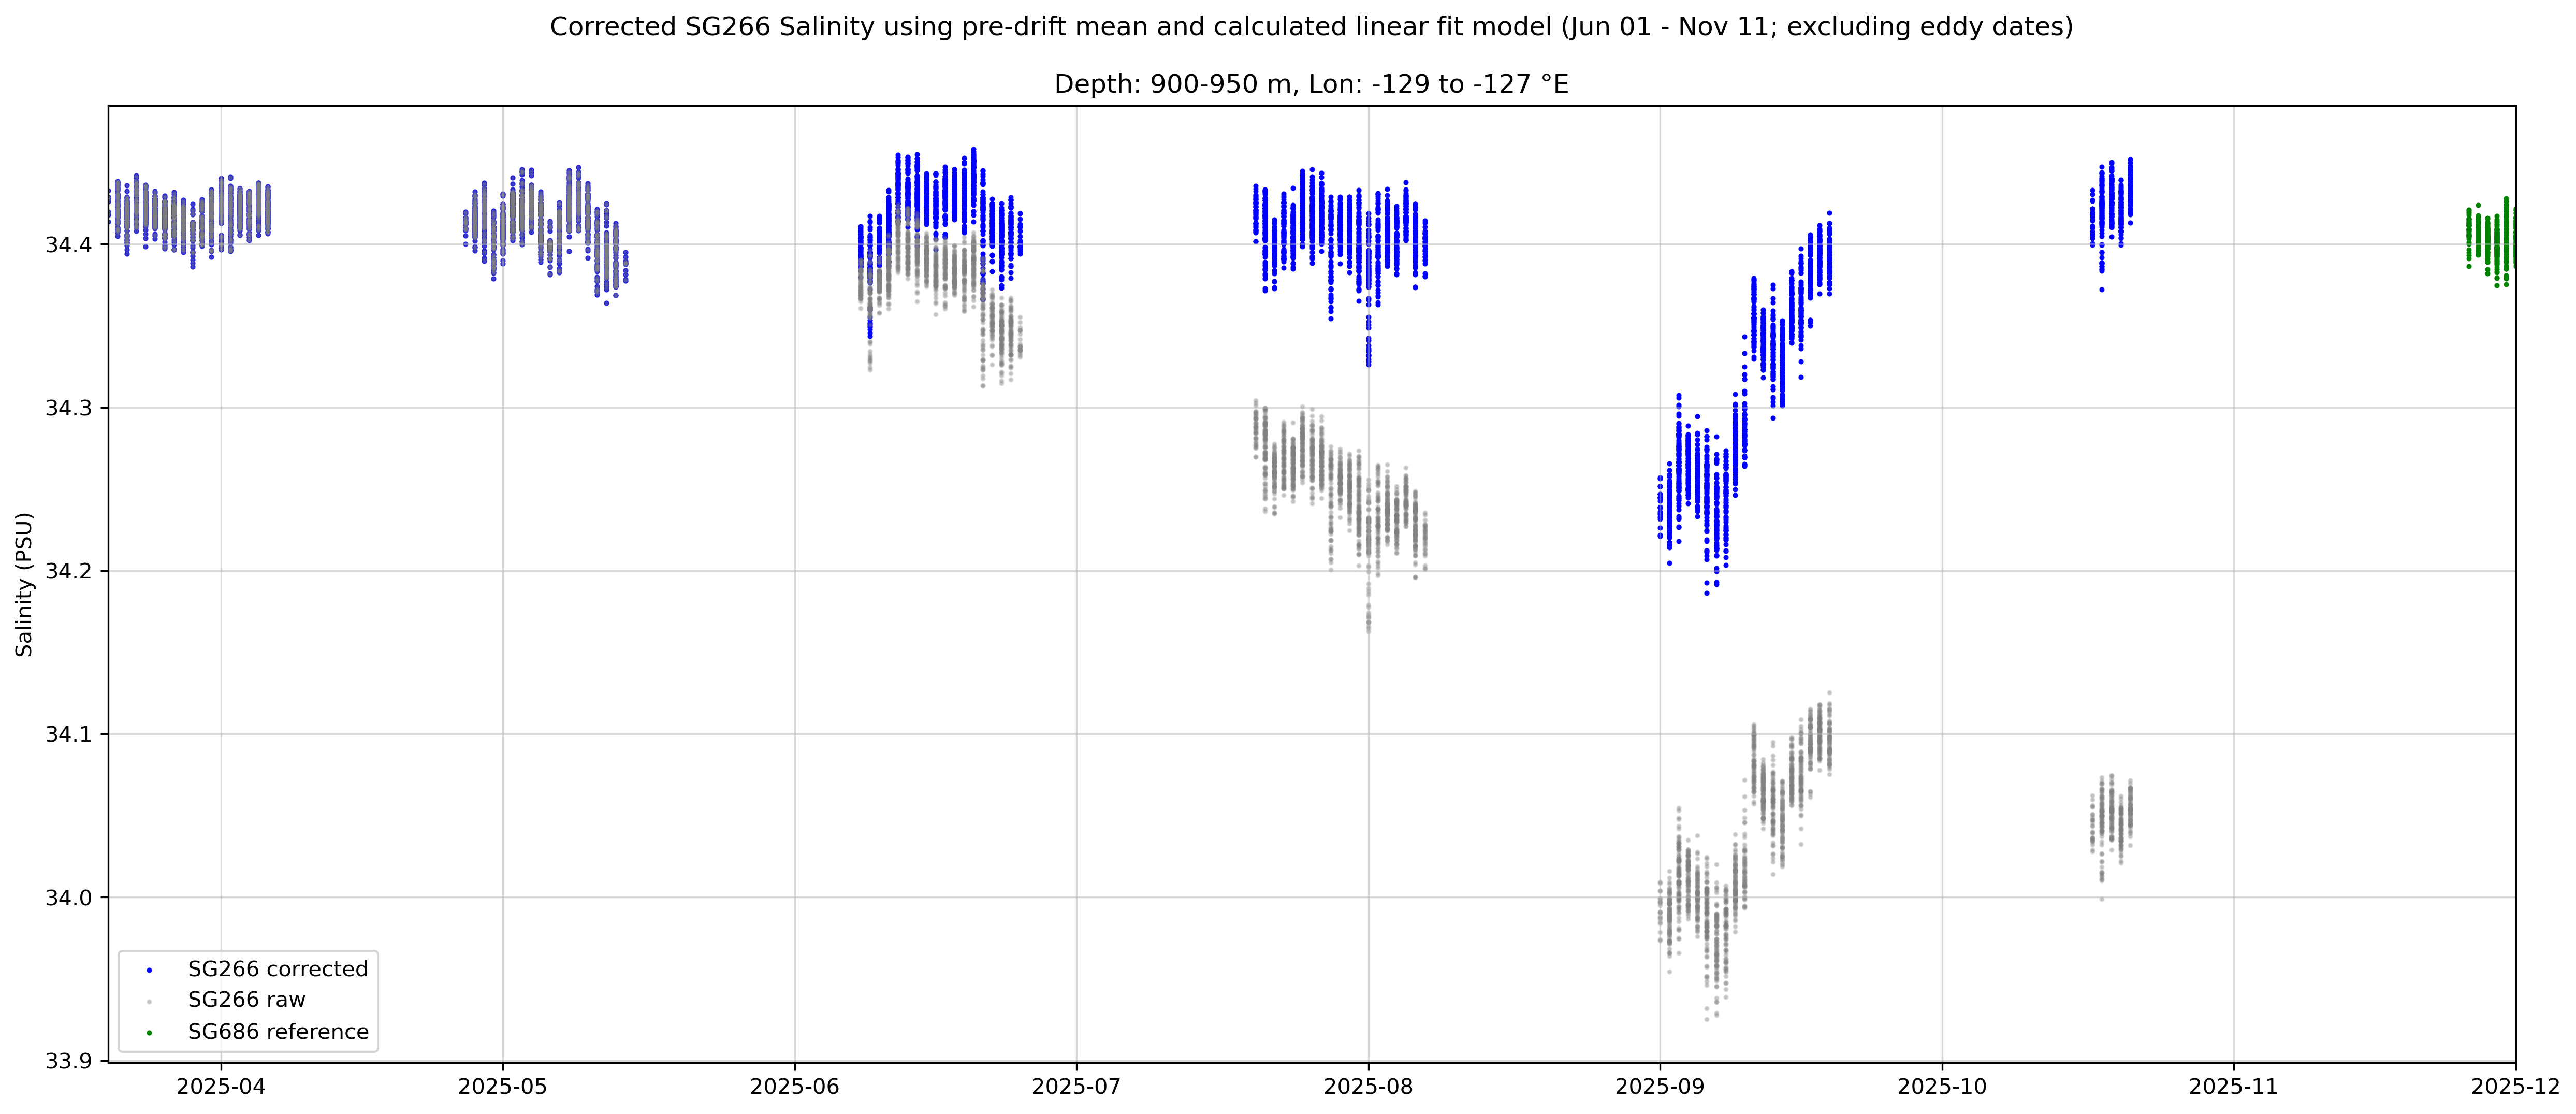

In [3]:
# ---------------------------------------------------------------------
# 1. Load WOA salinity climatology
# ---------------------------------------------------------------------

def woa_salt_temp(filepath_salt, filepath_temp, lat=41.625, lon_range=(-129.625, -127.375), depth_range=(900, 950)):
    # Load dataset (explicit engine)
    ds_salt = xr.open_dataset(filepath_salt, decode_times=False, engine='netcdf4')
    ds_temp = xr.open_dataset(filepath_temp, decode_times=False, engine='netcdf4')
    
    # Select lat/lon/depth
    ds_salt = ds_salt.sel(lat=lat, lon=slice(*lon_range), depth=slice(*depth_range))
    ds_temp = ds_temp.sel(lat=lat, lon=slice(*lon_range), depth=slice(*depth_range))
    
    # Determine month from filename: e.g., 's03' -> 3
    month_num = int(filepath_salt.split('_s')[1].split('_')[0])
    start = pd.Timestamp(f'2025-{month_num:02d}-01')
    end = start + pd.offsets.MonthEnd(0)
    
    # Duplicate dataset along time
    ds_salt_expanded = xr.concat([ds_salt, ds_salt], dim='time')
    ds_salt_expanded = ds_salt_expanded.assign_coords(time=("time", [start, end]))

    ds_temp_expanded = xr.concat([ds_temp, ds_temp], dim='time')
    ds_temp_expanded = ds_temp_expanded.assign_coords(time=("time", [start, end]))
    
    # Extract salinity and convert time to numeric
    woa_s = ds_salt_expanded['s_an']
    time_days = pd.to_datetime(woa_s['time'].values).astype('int64') / 1e9 / 86400
    woa_s = woa_s.assign_coords(time=time_days)

    woa_t = ds_temp_expanded['t_an']
    time_days = pd.to_datetime(woa_t['time'].values).astype('int64') / 1e9 / 86400
    woa_t = woa_t.assign_coords(time=time_days)
    
    return woa_s, woa_t

# List of files
filepaths_salt = [
    r'C:/Users/marqjace/TH_line/woa_climatology_data/salinity/woa18_decav_s01_04.nc',
    r'C:/Users/marqjace/TH_line/woa_climatology_data/salinity/woa18_decav_s02_04.nc',
    r'C:/Users/marqjace/TH_line/woa_climatology_data/salinity/woa18_decav_s03_04.nc',
    r'C:/Users/marqjace/TH_line/woa_climatology_data/salinity/woa18_decav_s04_04.nc',
    r'C:/Users/marqjace/TH_line/woa_climatology_data/salinity/woa18_decav_s05_04.nc',
    r'C:/Users/marqjace/TH_line/woa_climatology_data/salinity/woa18_decav_s06_04.nc',
    r'C:/Users/marqjace/TH_line/woa_climatology_data/salinity/woa18_decav_s07_04.nc',
    r'C:/Users/marqjace/TH_line/woa_climatology_data/salinity/woa18_decav_s08_04.nc',
    r'C:/Users/marqjace/TH_line/woa_climatology_data/salinity/woa18_decav_s09_04.nc',
    r'C:/Users/marqjace/TH_line/woa_climatology_data/salinity/woa18_decav_s10_04.nc',
    r'C:/Users/marqjace/TH_line/woa_climatology_data/salinity/woa18_decav_s11_04.nc',
    r'C:/Users/marqjace/TH_line/woa_climatology_data/salinity/woa18_decav_s12_04.nc',
]

filepaths_temp = [
    r'C:/Users/marqjace/TH_line/woa_climatology_data/temperature/woa18_decav_t01_04.nc',
    r'C:/Users/marqjace/TH_line/woa_climatology_data/temperature/woa18_decav_t02_04.nc',
    r'C:/Users/marqjace/TH_line/woa_climatology_data/temperature/woa18_decav_t03_04.nc',
    r'C:/Users/marqjace/TH_line/woa_climatology_data/temperature/woa18_decav_t04_04.nc',
    r'C:/Users/marqjace/TH_line/woa_climatology_data/temperature/woa18_decav_t05_04.nc',
    r'C:/Users/marqjace/TH_line/woa_climatology_data/temperature/woa18_decav_t06_04.nc',
    r'C:/Users/marqjace/TH_line/woa_climatology_data/temperature/woa18_decav_t07_04.nc',
    r'C:/Users/marqjace/TH_line/woa_climatology_data/temperature/woa18_decav_t08_04.nc',
    r'C:/Users/marqjace/TH_line/woa_climatology_data/temperature/woa18_decav_t09_04.nc',
    r'C:/Users/marqjace/TH_line/woa_climatology_data/temperature/woa18_decav_t10_04.nc',
    r'C:/Users/marqjace/TH_line/woa_climatology_data/temperature/woa18_decav_t11_04.nc',
    r'C:/Users/marqjace/TH_line/woa_climatology_data/temperature/woa18_decav_t12_04.nc',
]

# Dictionary to hold each month's salinity
woa_salt_dict = {}
woa_temp_dict = {}

for fpath_salt, fpath_temp in zip(filepaths_salt, filepaths_temp):
    salt_data, temp_data = woa_salt_temp(fpath_salt, fpath_temp)
    # Extract month abbreviation for dictionary key
    month_num = int(fpath_salt.split('_s')[1].split('_')[0])
    month_name = pd.Timestamp(f'2025-{month_num:02d}-01').strftime('%b').lower()  # 'jan', 'feb', etc.
    woa_salt_dict[month_name] = salt_data
    woa_temp_dict[month_name] = temp_data

# ---------------------------------------------------------------------
# 3. Prepare your CTD observation data
# ---------------------------------------------------------------------
ds_266 = xr.open_dataset(r"C:\Users\marqjace\seaglider\timeseries_nc\sg266_TH_Line_Mar_2025_timeseries.nc")
ds_686 = xr.open_dataset(r"C:\Users\marqjace\seaglider\sg686\TH_Line_11Nov25\sg686_2025_11_11_SG686_TH_Line_timeseries.nc")

temp_mask_266 = (ds_266['ctd_depth'] >= 900) & (ds_266['ctd_depth'] <= 950)  & (ds_266['longitude'] >= -129) & (ds_266['longitude'] <= -127) #& (pd.to_datetime('2025-06-01') <= ds_266['ctd_time'].values.astype('datetime64[s]')) #& (ds_266['ctd_time'].values.astype('datetime64[s]') <= pd.to_datetime('2025-11-19'))
temp_mask_686 = (ds_686['ctd_depth'] >= 900) & (ds_686['ctd_depth'] <= 950)  & (ds_686['longitude'] >= -129) & (ds_686['longitude'] <= -127)

indices_266 = np.where(temp_mask_266)[0]  # these are integer positions along 'ctd_data_point'
indices_686 = np.where(temp_mask_686)[0]  # these are integer positions along 'ctd_data_point'

# Select only those points
ds_266_sel = ds_266.isel(ctd_data_point=indices_266)
ds_686_sel = ds_686.isel(ctd_data_point=indices_686)

time_266 = ds_266_sel['ctd_time'].values.astype('datetime64[s]')
depth_266 = ds_266_sel['ctd_depth'].values
conductivity_266 = ds_266_sel['conductivity'].values
salinity_266 = ds_266_sel['salinity'].values
temperature_266 = ds_266_sel['temperature'].values
longitude_266 = ds_266_sel['longitude'].values

time_686 = ds_686_sel['ctd_time'].values.astype('datetime64[s]')
depth_686 = ds_686_sel['ctd_depth'].values
conductivity_686 = ds_686_sel['conductivity'].values
salinity_686 = ds_686_sel['salinity'].values
temperature_686 = ds_686_sel['temperature'].values
longitude_686 = ds_686_sel['longitude'].values

# ds_266_new = ds_266_sel.isel(ctd_data_point=~((time_266 >= np.datetime64("2025-08-17")) &
#                                       (time_266 <= np.datetime64("2025-10-01"))))

time_new_266 = ds_266_sel['ctd_time'].values.astype('float64') / 1e9 / 86400  # convert to days since epoch
depth_new_266 = ds_266_sel['ctd_depth'].values
conductivity_new_266 = ds_266_sel['conductivity'].values
salinity_new_266 = ds_266_sel['salinity'].values
temperature_new_266 = ds_266_sel['temperature'].values
longitude_new_266 = ds_266_sel['longitude'].values

time_new_686 = ds_686_sel['ctd_time'].values.astype('float64') / 1e9 / 86400  # convert to days since epoch
depth_new_686 = ds_686_sel['ctd_depth'].values
conductivity_new_686 = ds_686_sel['conductivity'].values
salinity_new_686 = ds_686_sel['salinity'].values
temperature_new_686 = ds_686_sel['temperature'].values
longitude_new_686 = ds_686_sel['longitude'].values

# ---------------------------------------------------------------------
# 4. Compute salinity anomaly for all months
# ---------------------------------------------------------------------

# Convert CTD times to datetime and numeric (days since epoch)
time_dt_266 = pd.to_datetime(ds_266_sel['ctd_time'].values)
time_days_266 = time_dt_266.values.astype('datetime64[ns]').astype('int64') / 1e9 / 86400

time_dt_686 = pd.to_datetime(ds_686_sel['ctd_time'].values)
time_days_686 = time_dt_686.values.astype('datetime64[ns]').astype('int64') / 1e9 / 86400

# Get month numbers (1–12) from each observation
months_266 = pd.to_datetime(time_dt_266).month

# Prepare output arrays
salinity_anom_all_266 = np.full_like(ds_266_sel['salinity'].values, np.nan, dtype='float64')
temperature_anom_all_266 = np.full_like(ds_266_sel['temperature'].values, np.nan, dtype='float64')
woa_salt_interp_all_266 = np.full_like(ds_266_sel['salinity'].values, np.nan, dtype='float64')
woa_temp_interp_all_266 = np.full_like(ds_266_sel['temperature'].values, np.nan, dtype='float64')

# Loop through each month and compute anomaly
for month_num in range(1, 13):
    month_mask_266 = months_266 == month_num
    if not np.any(month_mask_266):
        continue  # skip months with no observations
    
    # Extract the corresponding WOA salinity field
    month_name = pd.Timestamp(f'2025-{month_num:02d}-01').strftime('%b').lower()
    woa_salt_month = woa_salt_dict[month_name]
    woa_temp_month = woa_temp_dict[month_name]
    
    # Subset observations for this month
    time_m_266 = time_days_266[month_mask_266]
    depth_m_266 = ds_266_sel['ctd_depth'].values[month_mask_266]
    lon_m_266 = ds_266_sel['longitude'].values[month_mask_266]
    sal_m_266 = ds_266_sel['salinity'].values[month_mask_266]
    temp_m_266 = ds_266_sel['temperature'].values[month_mask_266]
    
    # Interpolate WOA salinity to match observation locations
    woa_salt_interp = woa_salt_month.interp(
        time=xr.DataArray(time_m_266, dims='ctd_point'),
        depth=xr.DataArray(depth_m_266, dims='ctd_point'),
        lon=xr.DataArray(lon_m_266, dims='ctd_point'),
        method='linear'
    )

    woa_temp_interp = woa_temp_month.interp(
        time=xr.DataArray(time_m_266, dims='ctd_point'),
        depth=xr.DataArray(depth_m_266, dims='ctd_point'),
        lon=xr.DataArray(lon_m_266, dims='ctd_point'),
        method='linear'
    )
    
    # Compute anomaly
    salinity_anom_all_266[month_mask_266] = sal_m_266 - woa_salt_interp.values
    temperature_anom_all_266[month_mask_266] = temp_m_266 - woa_temp_interp.values
    woa_salt_interp_all_266[month_mask_266] = woa_salt_interp.values
    woa_temp_interp_all_266[month_mask_266] = woa_temp_interp.values

# Convert numeric time back to datetime
time_dt_266 = np.datetime64('1970-01-01') + time_days_266 * np.timedelta64(1, 'D')
time_dt_686 = np.datetime64('1970-01-01') + time_days_686 * np.timedelta64(1, 'D')

# ---------------------------------------------------------------------
# 5. Plot results
# ---------------------------------------------------------------------

############### Salinity Lin Fit ###########################

mask_date = (
    (time_dt_266 >= np.datetime64('2025-06-01')) &
    ~((time_dt_266 >= np.datetime64('2025-08-31')) &
      (time_dt_266 <= np.datetime64('2025-10-01')))
)

mask_valid = ~np.isnan(time_days_266) & ~np.isnan(ds_266_sel['salinity'].values)

mask_all = mask_date & mask_valid

time_clean = time_days_266[mask_all]
salinity_clean = ds_266_sel['salinity'].values[mask_all]
time_dt_clean = time_dt_266[mask_all]

slope, intercept, r_value, p_value, std_err = linregress(time_clean, salinity_clean)
y_fit = slope * time_clean + intercept

fig, ax = plt.subplots(figsize=(20, 8), dpi=300)

ax.scatter(time_dt_clean, salinity_clean, s=2, c='b', label='SG266 Salinity')
ax.plot(time_dt_clean, y_fit, 'r', label=f'Fit: y={slope:.4f}x+{intercept:.2f}, R²={r_value**2:.2f}')
ax.scatter(time_dt_686, ds_686_sel['salinity'].values, s=2, c='g', label='SG686 Salinity')

ax.set_xlim(time_dt_266.min(), pd.to_datetime('2025-12-01'))
ax.set_ylabel('Salinity (PSU)')
ax.set_title('Salinity from SG266 -- Jun 01 to Nov 11\n\nDepth: 900-950 m, Lon: -129 to -127 °E')
ax.legend()
ax.grid(alpha=0.5)

# --- Remove drift only after June 1 -----

cutoff = np.datetime64('2025-06-01')
after_june_mask = time_dt_266 >= cutoff
before_june_mask = time_dt_266 < cutoff

mask_date = ~((time_dt_266 >= np.datetime64('2025-08-31')) &
              (time_dt_266 <= np.datetime64('2025-10-01')))

mask_valid = ~np.isnan(time_days_266) & ~np.isnan(ds_266_sel['salinity'].values) & mask_date
mask_fit = after_june_mask & mask_valid

# Fit drift only on post-June-1 data
time_fit = time_days_266[mask_fit]
sal_fit = ds_266_sel['salinity'].values[mask_fit]

slope, intercept, r_value, p_value, std_err = linregress(time_fit, sal_fit)

# Compute mean BEFORE June 1
sg266_before = ds_266_sel['salinity'].values[before_june_mask]
combined_good_values = np.concatenate([sg266_before, ds_686_sel['salinity'].values])
mean_before = np.nanmean(combined_good_values)

# Create adjusted salinity array
salinity_adj = ds_266_sel['salinity'].values.copy()

# Remove drift only after June 1, anchor to pre-June-1 mean
salinity_adj[after_june_mask] = (
    ds_266_sel['salinity'].values[after_june_mask]
    - (slope * time_days_266[after_june_mask] + intercept)
    + mean_before
)

# Plot
fig, ax = plt.subplots(figsize=(20, 8), dpi=300)
ax.scatter(time_dt_266, salinity_adj, s=2, c='b', label='SG266 corrected')
ax.scatter(time_dt_266, ds_266_sel['salinity'], s=2, c='gray', alpha=0.3, label='SG266 raw')
ax.scatter(time_dt_686, ds_686_sel['salinity'], s=2, c='g', label='SG686 reference')

ax.set_xlim(time_dt_266.min(), pd.to_datetime('2025-12-01'))
ax.set_ylabel('Salinity (PSU)')
ax.set_title('Corrected SG266 Salinity using pre-drift mean and calculated linear fit model (Jun 01 - Nov 11; excluding eddy dates)\n\nDepth: 900-950 m, Lon: -129 to -127 °E')
ax.legend()
ax.grid(alpha=0.5)

[34.43273  34.42836  34.42816  ... 34.38151  34.378483 34.377594]


c:\Users\marqjace\AppData\Local\anaconda3\envs\th_line\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


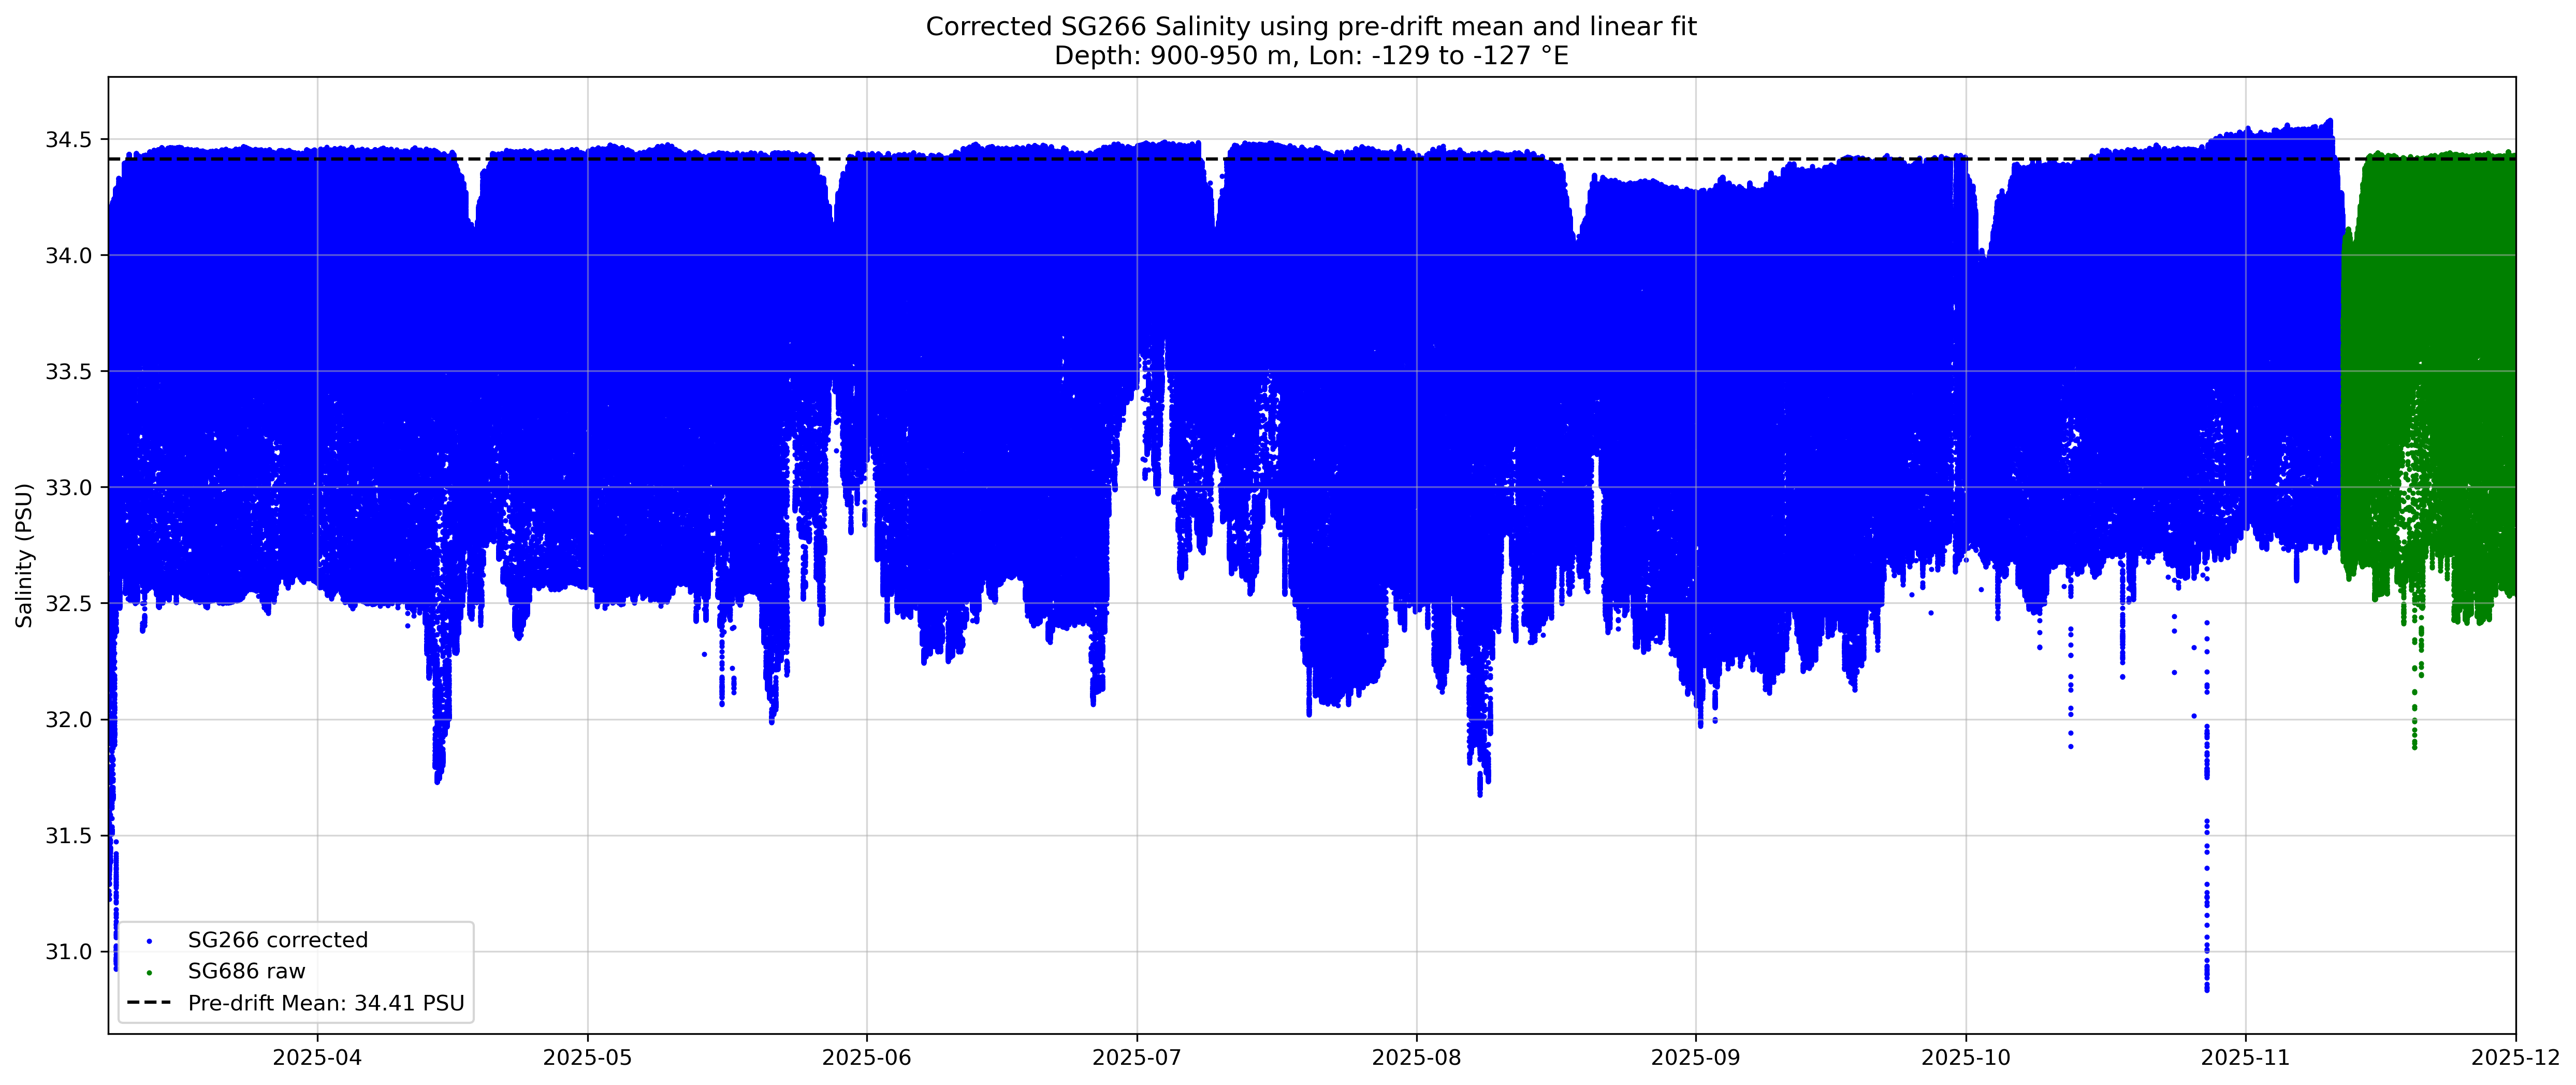

In [9]:
# --- Load datasets ---
ds = xr.open_dataset(r"C:\Users\marqjace\seaglider\timeseries_nc\sg266_TH_Line_Mar_2025_timeseries.nc")
ds_686 = xr.open_dataset(r"C:\Users\marqjace\seaglider\sg686\TH_Line_11Nov25\sg686_2025_11_11_SG686_TH_Line_timeseries.nc")

# --- Extract variables ---
time_date = ds['ctd_time'].values.astype('datetime64[s]')
time_int = time_date.astype('int64') / 1e9 / 86400  # convert to days since epoch
depth = ds['ctd_depth'].values
salinity = ds['salinity'].values
longitude = ds['longitude'].values

time_date_686 = ds_686['ctd_time'].values.astype('datetime64[s]')
time_int_686 = time_date_686.astype('int64') / 1e9 / 86400  # convert to days since epoch
depth_686 = ds_686['ctd_depth'].values
salinity_686 = ds_686['salinity'].values
longitude_686 = ds_686['longitude'].values

# --- Masks ---
after_june_mask = time_date >= np.datetime64('2025-06-01')
before_june_mask = time_date < np.datetime64('2025-06-01')  # strictly before June
exclude_mask = ~((time_date >= np.datetime64('2025-08-31')) & (time_date <= np.datetime64('2025-10-01')))
depth_mask = (depth >= 900) & (depth <= 950)
lon_mask = (longitude >= -129) & (longitude <= -127)
sal_mask = ~np.isnan(salinity)
time_mask = ~np.isnan(time_int)

sg686_depth_mask = (depth_686 >= 900) & (depth_686 <= 950)
sg686_lon_mask = (longitude_686 >= -129) & (longitude_686 <= -127)
sg686_salt_mask = ~np.isnan(salinity_686)
sg686_time_mask = ~np.isnan(time_int_686)

# Ensure all masks are 1D and same shape
mask_fit = after_june_mask & exclude_mask & depth_mask & lon_mask & sal_mask & time_mask
pre_june_mask = before_june_mask & depth_mask & lon_mask & sal_mask & time_mask
sg686_mask = sg686_depth_mask & sg686_lon_mask & sg686_salt_mask & sg686_time_mask

# --- Fit linear drift post-June ---
time_fit = time_int[mask_fit]
sal_fit = salinity[mask_fit]
slope, intercept, r_value, p_value, std_err = linregress(time_fit, sal_fit)

# --- Compute pre-June mean including SG686 (masked to pre-June) ---
sg686_salinity = ds_686['salinity'].values
sg_686_masked = sg686_salinity[sg686_mask]
sg266_before = salinity[pre_june_mask]
print(sg266_before)
combined_good_values = np.concatenate([sg266_before, sg_686_masked])
mean_before = np.nanmean(combined_good_values)

# --- Initialize corrected salinity array ---
salinity_adj = salinity.copy()

# --- Apply drift correction to ALL post-June points ---
salinity_adj[after_june_mask] = (
    salinity[after_june_mask]
    - (slope * time_int[after_june_mask] + intercept)
    + mean_before
)

drift_fit = slope * time_int + intercept

# --- Plot ---
fig, ax = plt.subplots(figsize=(20, 8), dpi=300)
ax.scatter(time_date, salinity_adj, s=2, c='b', label='SG266 corrected')
# ax.scatter(time_date, salinity, s=2, c='gray', alpha=0.1, label='SG266 raw')
ax.scatter(ds_686['ctd_time'].values.astype('datetime64[s]'), ds_686['salinity'].values, s=2, c='g', label='SG686 raw')
ax.axhline(mean_before, color='k', linestyle='--', label=f'Pre-drift Mean: {mean_before:.2f} PSU')

# ax.scatter(time_date, drift_fit, s=5, c='r', label='Drift fit region')

ax.set_xlim(time_date.min(), np.datetime64('2025-12-01'))
ax.set_ylabel('Salinity (PSU)')
ax.set_title('Corrected SG266 Salinity using pre-drift mean and linear fit\nDepth: 900-950 m, Lon: -129 to -127 °E')
ax.legend()
ax.grid(alpha=0.5)
plt.show()